/var/folders/sz/c0sdp7bx6ln2kkbd94zd0yyh0000ks/T/ipykernel_38122/233104061.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.06, 0, 1, 1))


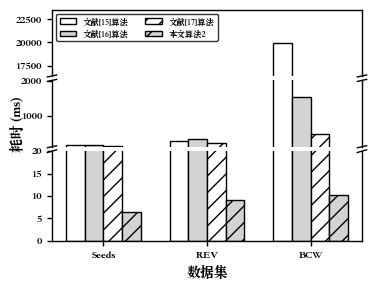

/var/folders/sz/c0sdp7bx6ln2kkbd94zd0yyh0000ks/T/ipykernel_38122/233104061.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.06, 0, 1, 1))


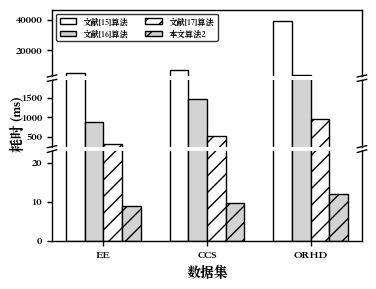

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置支持中文的字体，避免标签显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Songti SC', 'Arial Unicode MS'] # 适配 Windows/Mac
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# ================= 新增：全局调大字号设置 =================
plt.rcParams['axes.labelsize'] = 10  # 坐标轴标签字号 耗时 (ms), 属性个数
plt.rcParams['xtick.labelsize'] = 8 # X轴坐标值/刻度字号 "30%", "40%"
plt.rcParams['ytick.labelsize'] = 8 # Y轴刻度字号
plt.rcParams['legend.fontsize'] = 6 # 图例字号 本文算法
# ==========================================================

# ================= 新增：全局调大图框和刻度线宽 =================
plt.rcParams['axes.linewidth'] = 1.0      # 整个图表的边框（包括横纵坐标轴）线宽，默认约为0.8
plt.rcParams['xtick.major.width'] = 1.0   # X轴主刻度线的线宽
plt.rcParams['ytick.major.width'] = 1.0   # Y轴主刻度线的线宽

# ================= 新增：全局图例边框设置 =================
plt.rcParams['legend.edgecolor'] = 'black'  # 图例边框颜色
plt.rcParams['patch.linewidth'] = 1.0        # 这会影响图例边框的默认宽度

# 路径配置
base_dir = '../data/real'
output_dir = '../data/output8_2_gap'
os.makedirs(output_dir, exist_ok=True)

# 四列从左到右分别为文献[15]、文献[16]、文献[17]和本文算法
series_labels = ['文献[12]算法', '文献[13]算法', '文献[14]算法', '本文算法2']
bar_styles = [
    dict(color='white', edgecolor='black', linewidth=1.0),
    dict(color='lightgray', edgecolor='black', linewidth=1.0),
    dict(color='white', edgecolor='black', linewidth=1.0, hatch='//'),
    dict(color='lightgray', edgecolor='black', linewidth=1.0, hatch='//'),
]

width = 0.18 # 四柱图中每根柱子的宽度
na_bar_height = 1.0 # N/A 用统一稍高的矮柱显示


def dataset_name(filename):
    """
    从文件名中提取数据集名称，例如 1.Seeds_1.txt -> Seeds。
    """
    stem = os.path.splitext(filename)[0]
    return stem.split('.', 1)[1].rsplit('_', 1)[0]


def read_average_row(filepath):
    """
    读取文件最后一行，即前十次实验的平均运行时间。
    N/A 返回 None，绘图时使用矮柱并在柱上标注 N/A。
    """
    values = []
    if not os.path.exists(filepath):
        return [None, None, None, None]

    with open(filepath, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        return [None, None, None, None]

    parts = [part.strip() for part in lines[-1].split(',')]
    for part in parts[:4]:
        values.append(None if part == 'N/A' else float(part))

    while len(values) < 4:
        values.append(None)
    return values


def get_real_series(filenames):
    """
    按给定文件顺序读取 real 数据，并转置成四个算法序列。
    """
    rows = [read_average_row(os.path.join(base_dir, filename)) for filename in filenames]
    x_labels = [dataset_name(filename) for filename in filenames]
    return x_labels, [[row[i] for row in rows] for i in range(4)]


def display_values(values):
    return [na_bar_height if value is None else value for value in values]


def auto_break_limits(all_values):
    """
    根据数值分布自动生成断轴范围。
    当本文算法2远小于其它算法时，优先使用三段断轴，保留低值柱的可见高度。
    """
    numeric = sorted(value for value in all_values if value is not None)
    if len(numeric) < 2:
        return None

    max_value = max(numeric)
    if max_value < 100:
        return None

    small_values = [value for value in numeric if value <= 30]
    remaining_values = [value for value in numeric if value > 30]

    if small_values and remaining_values:
        low_top = max(max(small_values) * 1.90, 20)
        middle_bottom = min(remaining_values) * 0.78
        middle_top_candidates = [value for value in remaining_values if value <= max_value * 0.08]

        if middle_top_candidates:
            middle_top = max(middle_top_candidates) * 1.32
            high_values = [value for value in remaining_values if value > middle_top]
            if high_values:
                high_bottom = min(high_values) * 0.82
                if low_top < middle_bottom and middle_top < high_bottom:
                    return 'triple', low_top, middle_bottom, middle_top, high_bottom, max_value * 1.18

    low_cutoff = max_value * 0.08
    low_values = [value for value in numeric if value <= low_cutoff]
    high_values = [value for value in numeric if value > low_cutoff]

    if not low_values or not high_values:
        return None

    low_max = max(low_values)
    high_min = min(high_values)
    bottom_top = max(low_max * 1.32, na_bar_height * 2)
    top_bottom = high_min * 0.82

    if top_bottom <= bottom_top:
        return None

    return 'double', bottom_top, top_bottom, max_value * 1.18


def draw_bars(ax, x, series, use_labels=True):
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width
    for i, values in enumerate(series):
        label = series_labels[i] if use_labels else '_nolegend_'
        bars = ax.bar(x + offsets[i], display_values(values), width, label=label, **bar_styles[i])
        for bar, value in zip(bars, values):
            if value is None:
                bar.set_linestyle('--')


def annotate_na(ax, x, series, y_offset):
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width
    for i, values in enumerate(series):
        for j, value in enumerate(values):
            if value is None:
                ax.text(
                    x[j] + offsets[i],
                    na_bar_height + y_offset,
                    'N/A',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    rotation=90,
                )


def add_break_marks(upper_ax, lower_ax):
    d = 0.015
    kwargs = dict(color='black', clip_on=False, linewidth=1.0)
    upper_ax.plot((-d, +d), (-d, +d), transform=upper_ax.transAxes, **kwargs)
    upper_ax.plot((1 - d, 1 + d), (-d, +d), transform=upper_ax.transAxes, **kwargs)
    lower_ax.plot((-d, +d), (1 - d, 1 + d), transform=lower_ax.transAxes, **kwargs)
    lower_ax.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=lower_ax.transAxes, **kwargs)


def plot_and_save_four_bars(x_labels, series, output_filename):
    """
    绘制单独的四柱状图并保存到指定路径。
    数值跨度较大时使用断轴；算法2特别小的图使用三段断轴突出低值柱。
    """
    x = np.arange(len(x_labels))
    all_values = [value for values in series for value in values]
    break_limits = auto_break_limits(all_values)

    if break_limits and break_limits[0] == 'triple':
        _, low_top, middle_bottom, middle_top, high_bottom, high_top = break_limits
        fig, (ax_top, ax_middle, ax_bottom) = plt.subplots(
            3,
            1,
            sharex=True,
            figsize=(4, 3),
            gridspec_kw={'height_ratios': [1, 1, 1.35], 'hspace': 0.06},
        )

        draw_bars(ax_top, x, series, use_labels=True)
        draw_bars(ax_middle, x, series, use_labels=False)
        draw_bars(ax_bottom, x, series, use_labels=False)

        ax_bottom.set_ylim(0, low_top)
        ax_middle.set_ylim(middle_bottom, middle_top)
        ax_top.set_ylim(high_bottom, high_top)

        ax_top.spines['bottom'].set_visible(False)
        ax_middle.spines['top'].set_visible(False)
        ax_middle.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        ax_top.tick_params(labeltop=False, bottom=False)
        ax_middle.tick_params(labeltop=False, bottom=False)
        ax_bottom.xaxis.tick_bottom()
        add_break_marks(ax_top, ax_middle)
        add_break_marks(ax_middle, ax_bottom)

        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(x_labels)
        ax_bottom.set_xlabel('数据集')
        fig.text(0.02, 0.5, '耗时 (ms)', va='center', rotation='vertical', fontsize=10)
        ax_top.legend(ncol=2, loc='upper left')
        annotate_na(ax_bottom, x, series, low_top * 0.03)
        plt.tight_layout(rect=(0.06, 0, 1, 1))
    elif break_limits and break_limits[0] == 'double':
        _, bottom_top, top_bottom, top_max = break_limits
        fig, (ax_top, ax_bottom) = plt.subplots(
            2,
            1,
            sharex=True,
            figsize=(4, 3),
            gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.06},
        )

        draw_bars(ax_top, x, series, use_labels=True)
        draw_bars(ax_bottom, x, series, use_labels=False)

        ax_bottom.set_ylim(0, bottom_top)
        ax_top.set_ylim(top_bottom, top_max)

        ax_top.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        ax_top.tick_params(labeltop=False, bottom=False)
        ax_bottom.xaxis.tick_bottom()
        add_break_marks(ax_top, ax_bottom)

        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(x_labels)
        ax_bottom.set_xlabel('数据集')
        fig.text(0.02, 0.5, '耗时 (ms)', va='center', rotation='vertical', fontsize=10)
        ax_top.legend(ncol=2, loc='upper left')
        annotate_na(ax_bottom, x, series, bottom_top * 0.03)
        plt.tight_layout(rect=(0.06, 0, 1, 1))
    else:
        fig, ax = plt.subplots(figsize=(4, 3))
        draw_bars(ax, x, series, use_labels=True)

        max_display_value = max([na_bar_height] + [value for value in all_values if value is not None])
        ax.set_ylim(0, max_display_value * 1.18)
        ax.set_ylabel('耗时 (ms)')
        ax.set_xlabel('数据集')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels)
        ax.legend(ncol=2, loc='upper left')
        annotate_na(ax, x, series, max_display_value * 0.03)
        plt.tight_layout()

    save_path = os.path.join(output_dir, output_filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# 1. 绘制并保存 Seeds、REV、BCW 数据集柱状图
small_files = ['1.Seeds_2.txt', '2.REV_2.txt', '3.BCW_2.txt']
small_labels, small_series = get_real_series(small_files)
plot_and_save_four_bars(small_labels, small_series, 'real_small_time_comparison.png')

# 2. 绘制并保存 EE、CCS、ORHD 数据集柱状图
large_files = ['4.EE_2.txt', '5.CCS_2.txt', '6.ORHD_2.txt']
large_labels, large_series = get_real_series(large_files)
plot_and_save_four_bars(large_labels, large_series, 'real_large_time_comparison.png')
